# Project: India House Price Prediction
# Using Linear Regression

# Linear Regression

Linear regression is a supervised learning algorithm in machine learning that is used for predicting continuous numerical output values. It models the relationship between a dependent variable and one or more independent variables.

The linear relationship is represented by:

# y = mx + b

Where:
- **y** = output variable (predicted price)
- **x** = input variable (features)
- **m** = slope of the line (coefficient)
- **b** = y-intercept

## Evaluation Metrics

**RMSE:** Square root of Mean Squared Error — penalises large errors more.

**MAE:** Mean Absolute Error — average of absolute differences between actual and predicted values.

**R² Score:** Proportion of variance in the target explained by the model (1.0 = perfect).

# Pipeline
1. Data Loading
2. Preprocessing
3. Data Analysis (EDA)
4. Train / Test Split
5. Model Training (Linear Regression)
6. Evaluation
7. Actual vs Predicted Visualisation

# Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn import metrics

# 1. Data Loading

In [2]:
df = pd.read_csv('datasets/india_housing_prices.csv')
print('Shape:', df.shape)
df.head()

Shape: (250000, 23)


,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,1,Tamil Nadu,Chennai,Locality_84,Apartment,1,4740,489.76,0.10,1990,...,35,10,3,High,No,No,"Playground, Gym, Garden, Pool, Clubhouse",West,Owner,Ready_to_Move
1,2,Maharashtra,Pune,Locality_490,Independent House,3,2364,195.52,0.08,2008,...,17,8,1,Low,No,Yes,"Playground, Clubhouse, Pool, Gym, Garden",North,Builder,Under_Construction
2,3,Punjab,Ludhiana,Locality_167,Apartment,2,3642,183.79,0.05,1997,...,28,9,8,Low,Yes,No,"Clubhouse, Pool, Playground, Gym",South,Broker,Ready_to_Move
3,4,Rajasthan,Jodhpur,Locality_393,Independent House,2,2741,300.29,0.11,1991,...,34,5,7,High,Yes,Yes,"Playground, Clubhouse, Gym, Pool, Garden",North,Builder,Ready_to_Move
4,5,Rajasthan,Jaipur,Locality_466,Villa,4,4823,182.90,0.04,2002,...,23,4,9,Low,No,Yes,"Playground, Garden, Gym, Pool, Clubhouse",East,Builder,Ready_to_Move


In [3]:
# Column info
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 250000 entries, 0 to 249999
Data columns (total 23 columns):
 #   Column                          Non-Null Count   Dtype  
---  ------                          --------------   -----  
 0   ID                              250000 non-null  int64  
 1   State                           250000 non-null  str    
 2   City                            250000 non-null  str    
 3   Locality                        250000 non-null  str    
 4   Property_Type                   250000 non-null  str    
 5   BHK                             250000 non-null  int64  
 6   Size_in_SqFt                    250000 non-null  int64  
 7   Price_in_Lakhs                  250000 non-null  float64
 8   Price_per_SqFt                  250000 non-null  float64
 9   Year_Built                      250000 non-null  int64  
 10  Furnished_Status                250000 non-null  str    
 11  Floor_No                        250000 non-null  int64  
 12  Total_Floors               

# 2. Preprocessing

In [4]:
# Check for missing values
print('Missing values per column:')
df.isna().sum()

Missing values per column:


ID                                0
State                             0
City                              0
Locality                          0
Property_Type                     0
BHK                               0
Size_in_SqFt                      0
Price_in_Lakhs                    0
Price_per_SqFt                    0
Year_Built                        0
Furnished_Status                  0
Floor_No                          0
Total_Floors                      0
Age_of_Property                   0
Nearby_Schools                    0
Nearby_Hospitals                  0
Public_Transport_Accessibility    0
Parking_Space                     0
Security                          0
Amenities                         0
Facing                            0
Owner_Type                        0
Availability_Status               0
dtype: int64

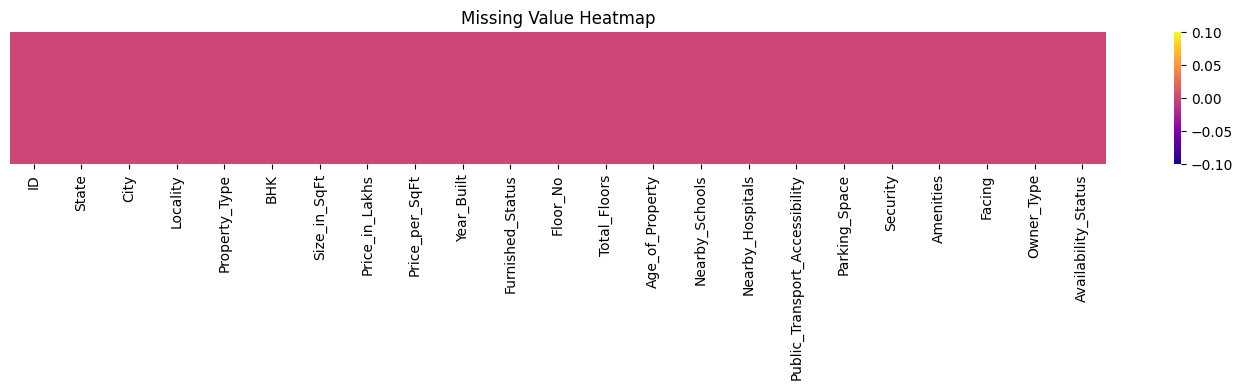

In [5]:
# Missing-value heatmap
plt.figure(figsize=(14, 4))
sns.heatmap(df.isna(), cmap='plasma', yticklabels=False, cbar=True)
plt.title('Missing Value Heatmap')
plt.tight_layout()
plt.show()

In [6]:
# Statistical summary
df.describe()

,ID,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
count,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000,250000.000000
mean,125000.500000,2.999396,2749.813216,254.586854,0.130597,2006.520012,14.966800,15.503004,18.479988,5.499860,5.498016
std,72168.927986,1.415521,1300.606954,141.349921,0.130747,9.808575,8.948047,8.671618,9.808575,2.878639,2.871860
min,1.000000,1.000000,500.000000,10.000000,0.000000,1990.000000,0.000000,1.000000,2.000000,1.000000,1.000000
25%,62500.750000,2.000000,1623.000000,132.550000,0.050000,1998.000000,7.000000,8.000000,10.000000,3.000000,3.000000
50%,125000.500000,3.000000,2747.000000,253.870000,0.090000,2007.000000,15.000000,15.000000,18.000000,5.000000,5.000000
75%,187500.250000,4.000000,3874.000000,376.880000,0.160000,2015.000000,23.000000,23.000000,27.000000,8.000000,8.000000
max,250000.000000,5.000000,5000.000000,500.000000,0.990000,2023.000000,30.000000,30.000000,35.000000,10.000000,10.000000


# 3. Data Analysis (EDA)

Correlation between features:
- **Positive correlation:** if one feature increases, the other also increases.
- **Negative correlation:** if one feature increases, the other decreases.

In [7]:
# Select only numeric features for correlation
numeric_cols = ['BHK', 'Size_in_SqFt', 'Price_in_Lakhs', 'Price_per_SqFt',
                'Year_Built', 'Floor_No', 'Total_Floors', 'Age_of_Property',
                'Nearby_Schools', 'Nearby_Hospitals']
correlation = df[numeric_cols].corr()
correlation

,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,Floor_No,Total_Floors,Age_of_Property,Nearby_Schools,Nearby_Hospitals
BHK,1.000000,-0.001033,-0.000980,0.001174,0.000917,0.001263,-0.002862,-0.000917,-0.000762,0.001162
Size_in_SqFt,-0.001033,1.000000,-0.002529,-0.614533,0.004135,-0.002775,-0.003451,-0.004135,0.001966,-0.001695
Price_in_Lakhs,-0.000980,-0.002529,1.000000,0.555625,0.002714,-0.001719,0.001283,-0.002714,0.000155,-0.002769
Price_per_SqFt,0.001174,-0.614533,0.555625,1.000000,-0.001212,-0.001906,0.004175,0.001212,-0.000094,-0.000145
Year_Built,0.000917,0.004135,0.002714,-0.001212,1.000000,-0.000686,0.003452,-1.000000,-0.000591,-0.002719
Floor_No,0.001263,-0.002775,-0.001719,-0.001906,-0.000686,1.000000,0.001169,0.000686,-0.000635,0.001428
Total_Floors,-0.002862,-0.003451,0.001283,0.004175,0.003452,0.001169,1.000000,-0.003452,-0.003093,-0.005867
Age_of_Property,-0.000917,-0.004135,-0.002714,0.001212,-1.000000,0.000686,-0.003452,1.000000,0.000591,0.002719
Nearby_Schools,-0.000762,0.001966,0.000155,-0.000094,-0.000591,-0.000635,-0.003093,0.000591,1.000000,-0.002246
Nearby_Hospitals,0.001162,-0.001695,-0.002769,-0.000145,-0.002719,0.001428,-0.005867,0.002719,-0.002246,1.000000


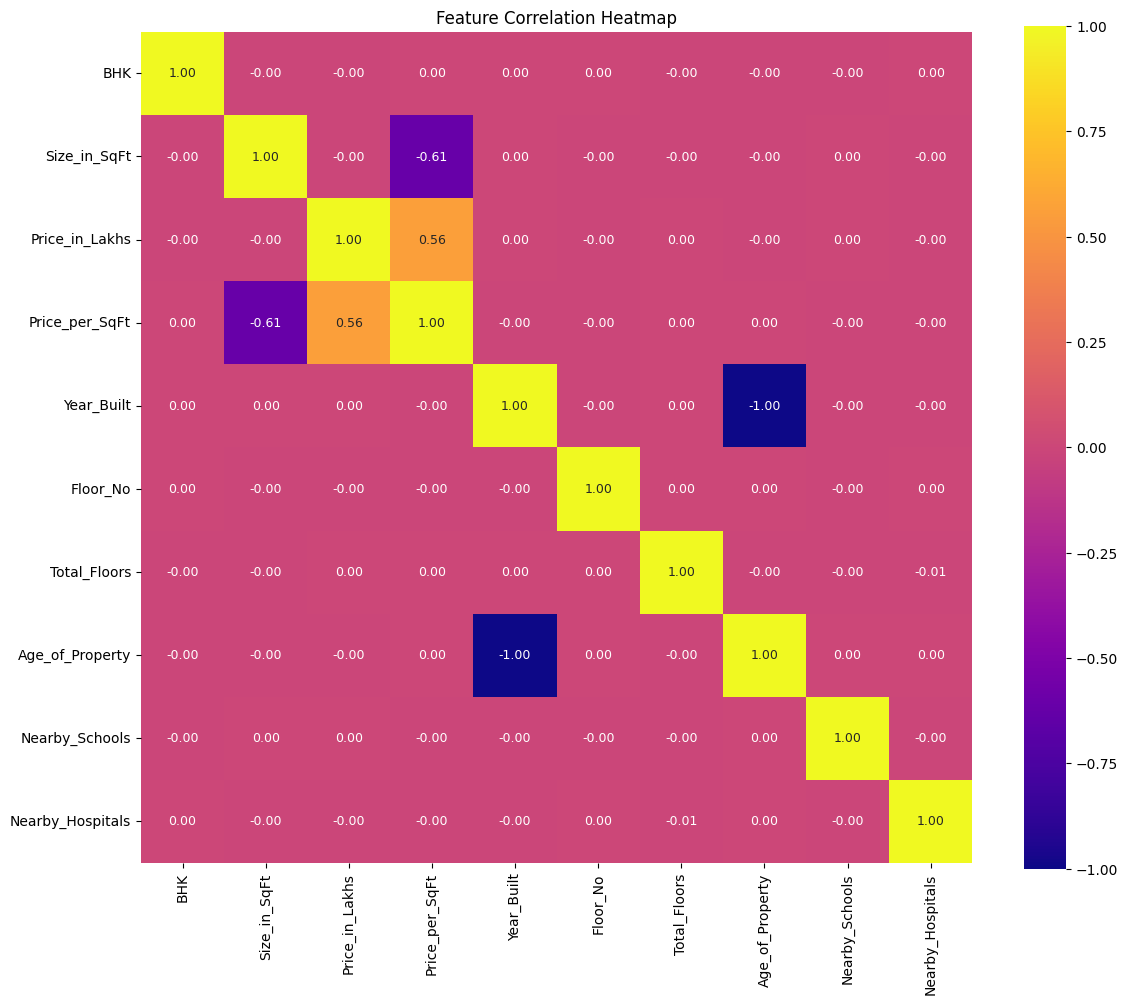

In [8]:
# Correlation Heatmap
plt.figure(figsize=(12, 10))
sns.heatmap(
    correlation,
    cbar=True,
    fmt='.2f',
    annot=True,
    annot_kws={'size': 9},
    square=True,
    cmap='plasma'
)
plt.title('Feature Correlation Heatmap')
plt.tight_layout()
plt.show()

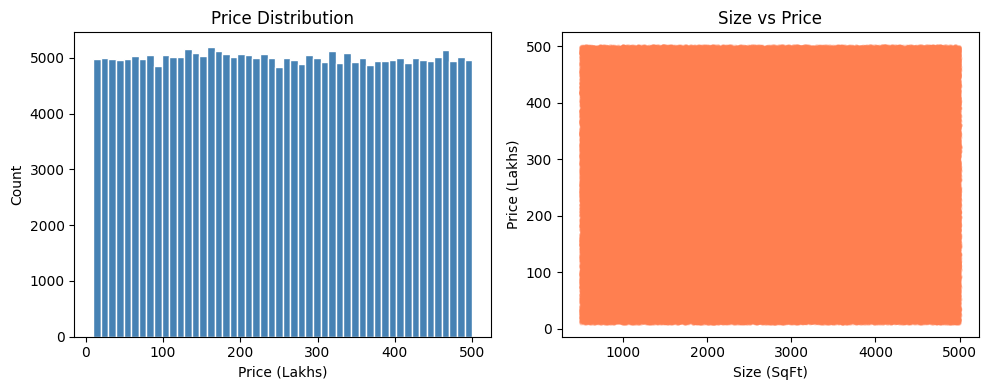

In [9]:
# Price distribution
plt.figure(figsize=(10, 4))
plt.subplot(1, 2, 1)
plt.hist(df['Price_in_Lakhs'], bins=50, color='steelblue', edgecolor='white')
plt.xlabel('Price (Lakhs)')
plt.ylabel('Count')
plt.title('Price Distribution')

plt.subplot(1, 2, 2)
plt.scatter(df['Size_in_SqFt'], df['Price_in_Lakhs'], alpha=0.2, s=5, color='coral')
plt.xlabel('Size (SqFt)')
plt.ylabel('Price (Lakhs)')
plt.title('Size vs Price')
plt.tight_layout()
plt.show()

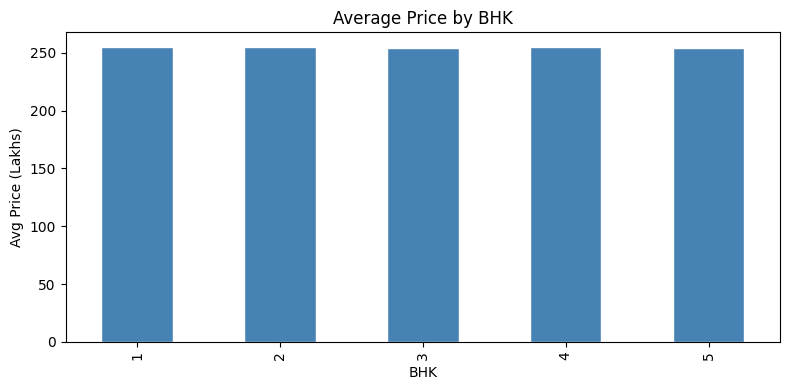

In [10]:
# Average price by BHK
avg_price_bhk = df.groupby('BHK')['Price_in_Lakhs'].mean()
plt.figure(figsize=(8, 4))
avg_price_bhk.plot(kind='bar', color='steelblue', edgecolor='white')
plt.xlabel('BHK')
plt.ylabel('Avg Price (Lakhs)')
plt.title('Average Price by BHK')
plt.tight_layout()
plt.show()

# 4. Train / Test Split

We use numeric features only for the Linear Regression model.
Target variable: **Price_in_Lakhs**

In [12]:
# Select numeric features (drop ID and Price_per_SqFt to avoid data leakage)
features = ['BHK', 'Size_in_SqFt', 'Year_Built', 'Floor_No',
            'Total_Floors', 'Age_of_Property', 'Nearby_Schools', 'Nearby_Hospitals']

X = df[features]
y = df['Price_in_Lakhs']

print('Feature matrix shape:', X.shape)
print('Target shape:', y.shape)

Feature matrix shape: (250000, 8)
Target shape: (250000,)


In [13]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.1, random_state=42
)
print('Training set:', X_train.shape[0], 'samples')
print('Test set    :', X_test.shape[0], 'samples')

Training set: 225000 samples
Test set    : 25000 samples


In [14]:
print('X_train shape:', X_train.shape)
print('X_test shape :', X_test.shape)
print('y_train shape:', y_train.shape)
print('y_test shape :', y_test.shape)

X_train shape: (225000, 8)
X_test shape : (25000, 8)
y_train shape: (225000,)
y_test shape : (25000,)


# 5. Model Training — Linear Regression

In [15]:
# Feature scaling improves numerical stability for linear models
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

In [16]:
model = LinearRegression()
model.fit(X_train_scaled, y_train)
print('Model trained successfully.')
print('Intercept:', round(model.intercept_, 4))

coef_df = pd.DataFrame({'Feature': features, 'Coefficient': model.coef_})
coef_df = coef_df.sort_values('Coefficient', ascending=False)
print(coef_df.to_string(index=False))

Model trained successfully.
Intercept: 254.633
         Feature  Coefficient
    Total_Floors     0.238531
      Year_Built     0.236245
             BHK     0.034604
  Nearby_Schools     0.011538
    Size_in_SqFt    -0.212109
 Age_of_Property    -0.236245
        Floor_No    -0.358743
Nearby_Hospitals    -0.364390


# 6. Evaluation

In [17]:
# Predictions on training data
training_data_prediction = model.predict(X_train_scaled)

mae_train  = metrics.mean_absolute_error(y_train, training_data_prediction)
mse_train  = metrics.mean_squared_error(y_train, training_data_prediction)
rmse_train = np.sqrt(mse_train)
r2_train   = metrics.r2_score(y_train, training_data_prediction)

print('--- Training Set ---')
print(f'MAE  : {mae_train:.4f}')
print(f'MSE  : {mse_train:.4f}')
print(f'RMSE : {rmse_train:.4f}')
print(f'R2   : {r2_train:.4f}')

--- Training Set ---
MAE  : 122.4729
MSE  : 19992.5402
RMSE : 141.3950
R2   : 0.0000


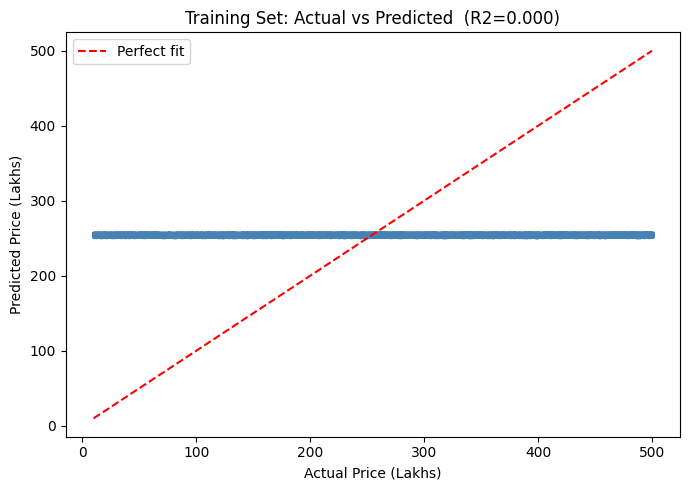

In [18]:
# Scatter plot: training predictions vs actuals
plt.figure(figsize=(7, 5))
plt.scatter(y_train, training_data_prediction, alpha=0.3, s=5, color='steelblue')
lims = [y_train.min(), y_train.max()]
plt.plot(lims, lims, 'r--', linewidth=1.5, label='Perfect fit')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title(f'Training Set: Actual vs Predicted  (R2={r2_train:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

# 7. Prediction on Test Data

In [19]:
test_data_prediction = model.predict(X_test_scaled)

mae_test  = metrics.mean_absolute_error(y_test, test_data_prediction)
mse_test  = metrics.mean_squared_error(y_test, test_data_prediction)
rmse_test = np.sqrt(mse_test)
r2_test   = metrics.r2_score(y_test, test_data_prediction)

print('--- Test Set ---')
print(f'MAE  : {mae_test:.4f}')
print(f'MSE  : {mse_test:.4f}')
print(f'RMSE : {rmse_test:.4f}')
print(f'R2   : {r2_test:.4f}')

--- Test Set ---
MAE  : 122.0911
MSE  : 19859.7482
RMSE : 140.9246
R2   : -0.0000


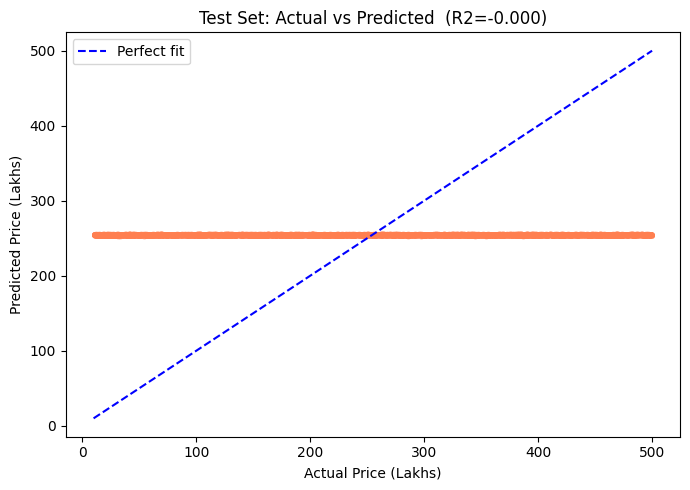

In [20]:
# Scatter plot: test predictions vs actuals
plt.figure(figsize=(7, 5))
plt.scatter(y_test, test_data_prediction, alpha=0.3, s=5, color='coral')
lims = [y_test.min(), y_test.max()]
plt.plot(lims, lims, 'b--', linewidth=1.5, label='Perfect fit')
plt.xlabel('Actual Price (Lakhs)')
plt.ylabel('Predicted Price (Lakhs)')
plt.title(f'Test Set: Actual vs Predicted  (R2={r2_test:.3f})')
plt.legend()
plt.tight_layout()
plt.show()

# Dataset Sample

Save a 100-row sample of the India housing dataset for quick reference and testing.

In [21]:
import os

sample = df.sample(n=100, random_state=42).reset_index(drop=True)
sample_path = os.path.join('datasets', 'india_housing_sample.csv')
sample.to_csv(sample_path, index=False)

print(f'Saved {len(sample)} rows -> {sample_path}')
sample.head(10)

Saved 100 rows -> datasets\india_housing_sample.csv


,ID,State,City,Locality,Property_Type,BHK,Size_in_SqFt,Price_in_Lakhs,Price_per_SqFt,Year_Built,...,Age_of_Property,Nearby_Schools,Nearby_Hospitals,Public_Transport_Accessibility,Parking_Space,Security,Amenities,Facing,Owner_Type,Availability_Status
0,38684,Haryana,Gurgaon,Locality_123,Independent House,4,692,256.62,0.37,2022,...,3,6,6,Medium,Yes,No,"Playground, Pool",South,Builder,Ready_to_Move
1,64940,Andhra Pradesh,Vishakhapatnam,Locality_74,Apartment,2,3094,86.04,0.03,2015,...,10,3,8,Medium,No,No,"Gym, Clubhouse, Pool, Garden",South,Builder,Under_Construction
2,3955,Madhya Pradesh,Bhopal,Locality_486,Apartment,3,4993,237.86,0.05,1995,...,30,10,1,High,No,No,"Gym, Pool, Playground, Clubhouse, Garden",West,Owner,Ready_to_Move
3,120375,Punjab,Ludhiana,Locality_13,Villa,1,2461,339.41,0.14,2018,...,7,10,5,Low,Yes,No,"Pool, Gym",South,Owner,Under_Construction
4,172862,Haryana,Faridabad,Locality_22,Independent House,2,4535,124.99,0.03,1991,...,34,5,9,Medium,No,Yes,Pool,South,Builder,Under_Construction
5,149304,Delhi,New Delhi,Locality_62,Villa,1,3228,35.17,0.01,2019,...,6,7,7,Low,Yes,No,"Clubhouse, Gym",West,Owner,Under_Construction
6,111627,Madhya Pradesh,Indore,Locality_248,Apartment,1,3461,275.75,0.08,2002,...,23,2,8,High,No,Yes,"Playground, Pool, Gym, Clubhouse, Garden",North,Broker,Under_Construction
7,164554,Maharashtra,Pune,Locality_464,Apartment,3,2653,374.76,0.14,2020,...,5,9,9,Low,Yes,No,"Pool, Clubhouse, Playground, Gym, Garden",East,Builder,Under_Construction
8,55780,Karnataka,Bangalore,Locality_215,Villa,3,2217,476.35,0.21,2020,...,5,9,8,Medium,No,No,"Garden, Playground, Gym, Clubhouse, Pool",South,Broker,Under_Construction
9,141991,Jharkhand,Jamshedpur,Locality_127,Apartment,3,4974,208.00,0.04,2007,...,18,9,4,Medium,Yes,No,"Garden, Playground, Gym, Pool",South,Owner,Under_Construction
